In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_theme(style='whitegrid')

In [2]:
conn = sqlite3.connect(r"..\inventory.db")
purchases_df = pd.read_sql_query("SELECT * FROM purchases",conn)

In [4]:
purchases_df.shape

(2372474, 16)

In [5]:
purchases_df.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber',
       'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate',
       'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification'],
      dtype='object')

In [6]:
purchases_df.head(10)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1
5,5_SUTTON_3348,5,3348,Bombay Sapphire Gin,1.75L,480,BACARDI USA INC,8106,2023-12-20,2024-01-02,2024-01-12,2024-02-05,22.38,6,134.28,1
6,1_HARDERSFIELD_8358,1,8358,Bacardi 151 Proof,750mL,480,BACARDI USA INC,8106,2023-12-20,2024-01-01,2024-01-12,2024-02-05,14.49,12,173.88,1
7,30_CULCHETH_4903,30,4903,Bacardi Superior Rum,200mL,480,BACARDI USA INC,8106,2023-12-20,2024-01-01,2024-01-12,2024-02-05,2.87,48,137.76,1
8,34_PITMERDEN_3782,34,3782,Grey Goose Le Citron Vodka,750mL,480,BACARDI USA INC,8106,2023-12-20,2024-01-02,2024-01-12,2024-02-05,18.89,5,94.45,1
9,1_HARDERSFIELD_4233,1,4233,Castillo Silver Label Rum,1.75L,480,BACARDI USA INC,8106,2023-12-20,2024-01-01,2024-01-12,2024-02-05,7.87,23,181.01,1


# Total unique brands purchased

In [10]:
purchases_df['Brand'].nunique()

10664

# Total unique stores

In [11]:
purchases_df['Store'].nunique()

80

# Total vendors

In [12]:
purchases_df['VendorNumber'].nunique()

126

In [13]:
purchases_df['PODate'] = pd.to_datetime(purchases_df['PODate'])

In [14]:
purchases_df['PODate'].min()

Timestamp('2023-12-20 00:00:00')

In [15]:
purchases_df['PODate'].max()

Timestamp('2024-12-23 00:00:00')

# Monthly purchase amount trend

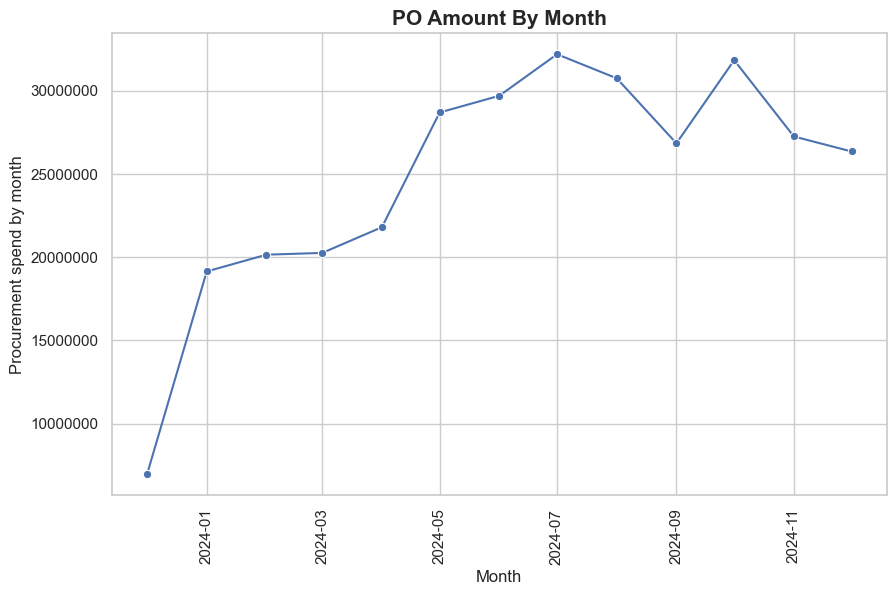

In [63]:
monthly_Purchase = (purchases_df.groupby('PO_month', as_index=False)['Dollars'].sum().sort_values('PO_month'))

fig, ax = plt.subplots(figsize=(10,6))

sns.lineplot(data=monthly_Purchase,x='PO_month',y='Dollars',marker='o',ax=ax)

ax.set_title('PO Amount By Month', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Procurement spend by month')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)

plt.show()

# Vendors by Procurement lead time

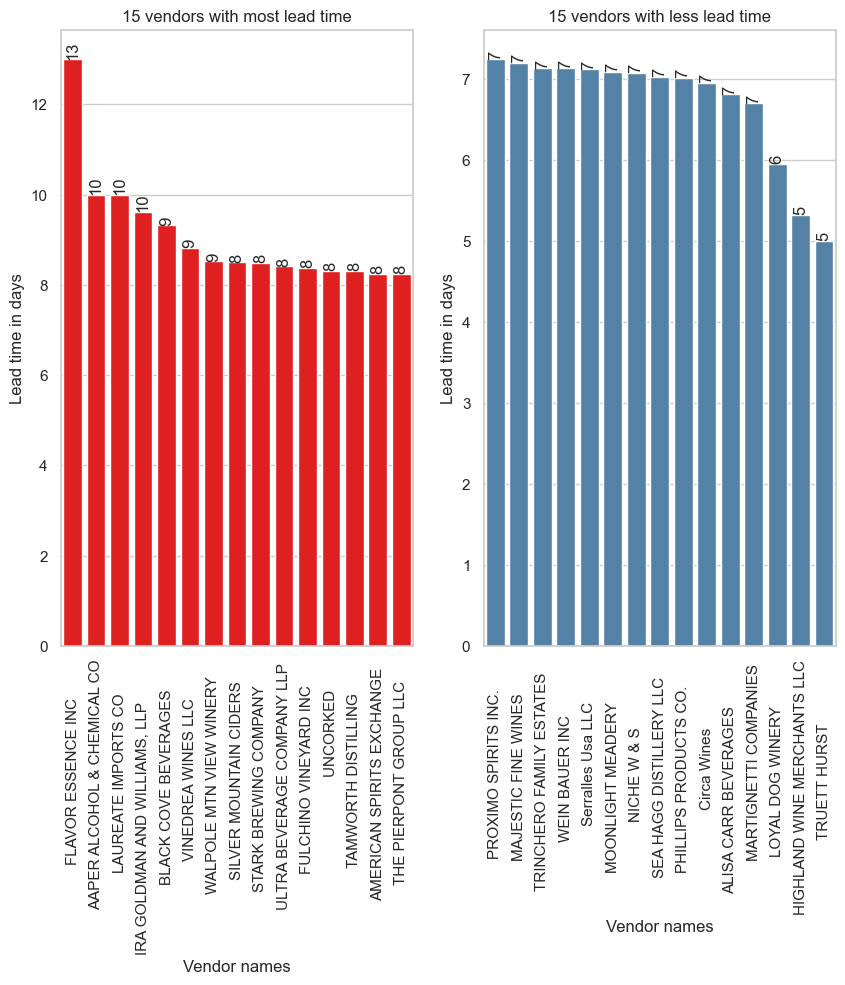

In [19]:
purchases_df['PODate'] = pd.to_datetime(purchases_df['PODate'])
purchases_df['ReceivingDate'] = pd.to_datetime(purchases_df['ReceivingDate'])
purchases_df['Lead_time_in_days'] = (purchases_df['ReceivingDate'] - purchases_df['PODate']).dt.days

Vendors_lead_time = purchases_df.groupby('VendorName', as_index=False)['Lead_time_in_days'].mean().sort_values(by='Lead_time_in_days', ascending=False)
Most_lead_time = Vendors_lead_time.head(15)
Least_lead_time = Vendors_lead_time.tail(15)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,8))
sns.barplot(data=Most_lead_time, x='VendorName', y='Lead_time_in_days', color='red', ax=axes[0],order=Most_lead_time.sort_values('Lead_time_in_days', ascending=False)['VendorName'])
axes[0].set_title('15 vendors with most lead time')
axes[0].set_xlabel('Vendor names')
axes[0].set_ylabel('Lead time in days')
axes[0].tick_params(axis='x', labelrotation=90)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', rotation=90)
    
sns.barplot(data=Least_lead_time, x='VendorName', y='Lead_time_in_days', color='steelblue', ax=axes[1],order=Least_lead_time.sort_values('Lead_time_in_days', ascending=False)['VendorName'])
axes[1].set_title('15 vendors with less lead time')
axes[1].set_xlabel('Vendor names')
axes[1].set_ylabel('Lead time in days')
axes[1].tick_params(axis='x', labelrotation=90)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', rotation=90)



# Lead time distribution 

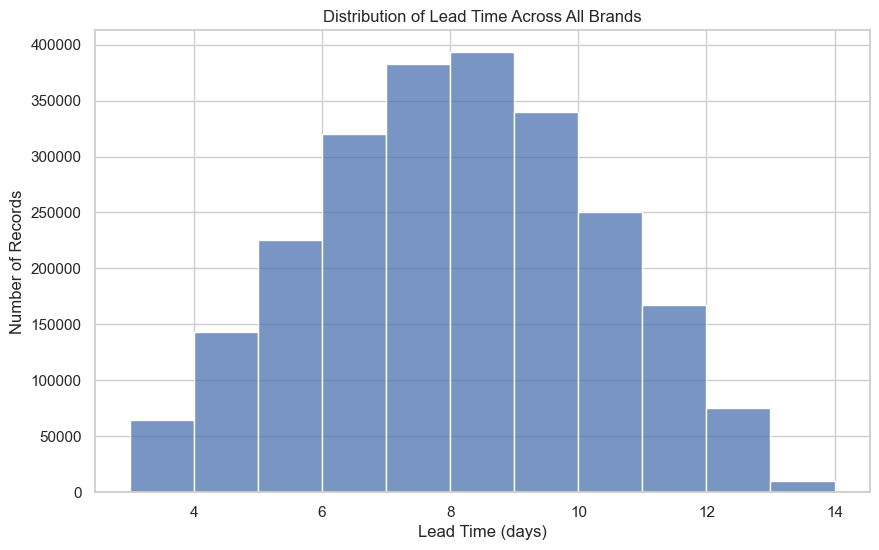

In [74]:
plt.figure(figsize=(10,6))

sns.histplot(data=purchases_df,x='Lead_time_in_days',bins=13,binwidth=1,kde=False)

plt.title('Distribution of Lead Time Across All Brands')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Records')
plt.show()

- Most purchase orders are received within 7–9 days.
- A small number of orders experience significantly longer lead times, suggesting possible supply-chain delays

# Brands associated with more lead time

In [77]:
Prod_lead_time = purchases_df.groupby('Brand', as_index=False)['Lead_time_in_days'].mean().sort_values(by='Lead_time_in_days', ascending=False)
Prod_lead_time.head(15)

,Brand,Lead_time_in_days
4237,14347,14.0
2659,5795,13.0
5024,17528,13.0
6663,22624,13.0
5123,18073,13.0
2827,6416,13.0
125,351,13.0
597,1277,12.2
8965,27786,12.2
8984,27811,12.2


# Purchase quantity vs Lead time

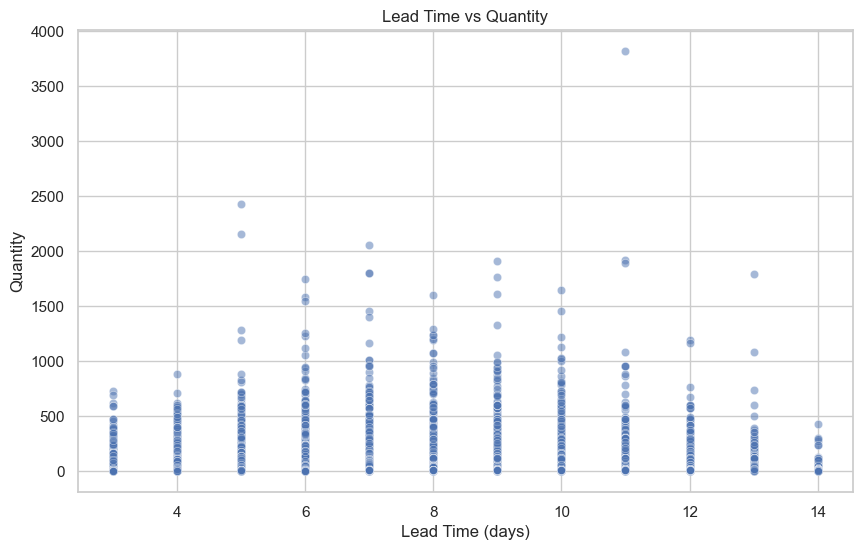

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=purchases_df,x='Lead_time_in_days',y='Quantity', alpha=0.5)

plt.title('Lead Time vs Quantity')
plt.xlabel('Lead Time (days)')
plt.ylabel('Quantity')
plt.show()

# Vendors procurement constribution

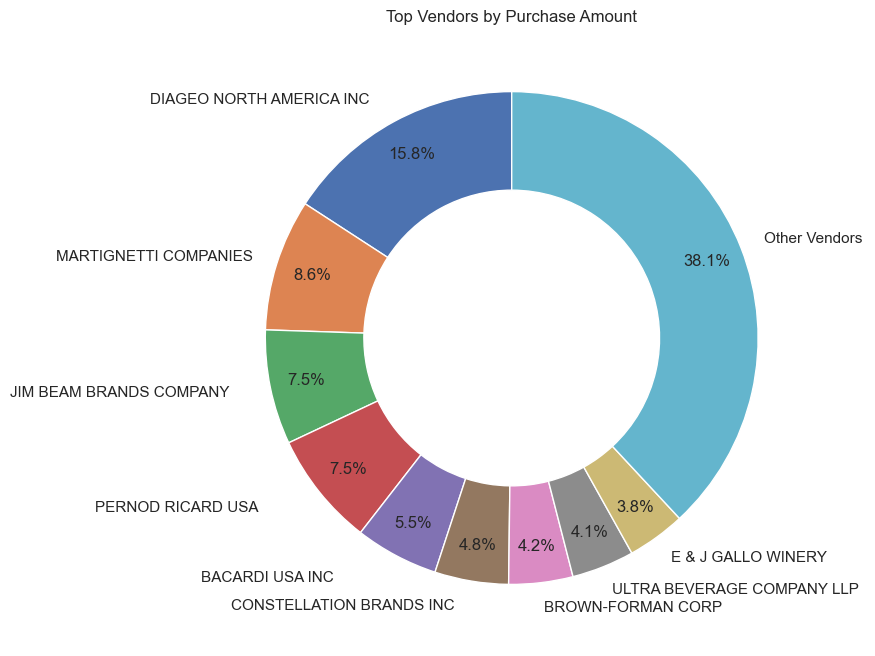

In [88]:
Vendors_amount = purchases_df.groupby('VendorName', as_index=False)['Dollars'].sum().sort_values(by='Dollars', ascending=False)
other_vendor= Vendors_amount.iloc[9:]['Dollars'].sum()
Vendors_amount = Vendors_amount.iloc[0:9]
Vendors_amount.loc[len(Vendors_amount)] = ['Other Vendors', other_vendor]

plt.figure(figsize=(8, 8))

plt.pie( Vendors_amount['Dollars'],labels=Vendors_amount['VendorName'],autopct='%1.1f%%',startangle=90,wedgeprops=dict(width=0.4, edgecolor='white'),pctdistance=0.85)
plt.title('Top Vendors by Purchase Amount')

plt.show()

- Procurement spend is concentrated among a relatively small number of suppliers
- 10 vendors contribute for ~ 60% of procurement
- The largest supplier contributes approximately 16% of total procurement spend

# Vendors procurement perfomance scorecard

In [115]:
Vendors_KPIs = purchases_df.groupby('VendorName', as_index=False).agg(
    {'PONumber':'count', 'Quantity':'sum', 'Lead_time_in_days':'mean', 'Dollars':'sum'}
)
Vendors_KPIs.columns = ['Vendor name', 'Total_POs', 'Total_quantities', 'Avg_lead_time_days', 'Total_purchase_amount']
Vendors_KPIs['Average_purchase_amount'] = Vendors_KPIs['Total_purchase_amount'] / Vendors_KPIs['Total_POs']
Vendors_KPIs.sort_values(by='Average_purchase_amount', ascending=False).head(20)

,Vendor name,Total_POs,Total_quantities,Avg_lead_time_days,Total_purchase_amount,Average_purchase_amount
97,STARK BREWING COMPANY,41,1212,8.487805,25961.04,633.196098
2,ALISA CARR BEVERAGES,63,438,6.809524,34951.68,554.788571
120,VINEYARD BRANDS LLC,23,371,8.086957,10951.51,476.152609
48,"IRA GOLDMAN AND WILLIAMS, LLP",13,328,9.615385,5630.88,433.144615
10,BLACK COVE BEVERAGES,44,919,9.318182,14465.06,328.751364
68,MOET HENNESSY USA INC,29412,427867,7.431355,9472995.20,322.079260
46,"HOOD RIVER DISTILLERS, Inc.",83,1137,7.807229,24035.96,289.589880
108,TAMWORTH DISTILLING,153,1990,8.307190,41036.44,268.212026
34,EDRINGTON AMERICAS,7081,62542,7.332298,1882832.84,265.899285
84,REMY COINTREAU USA INC,12666,142363,7.582899,3354958.28,264.879068


# Products with Highest Average Purchase Price

In [110]:
purchases_df.groupby('Description', as_index=False)['PurchasePrice'].mean().sort_values(by='PurchasePrice', ascending=False).head(15)

,Description,PurchasePrice
6794,Patron En Lalique Tequila,5681.81
4048,Glenmorangie Pride,4264.70
4356,Hennessy Richard Cognac,3352.93
4029,Glenfiddich 1978 Rare Collct,2713.17
7119,Port Ellen 32 Yr Single Malt,2661.86
2628,Courvoisier L'Essence Cognac,2518.51
7402,Remy Martin Louis XIII,2290.07
8409,Stolichnaya Elit Pristine,2222.21
4353,Hennessy Paradis Imperial,2109.37
1218,Brora 37 Yr Old Single Malt,1574.80


# ABC Analysis of Procurement Spend (Pareto Analysis)

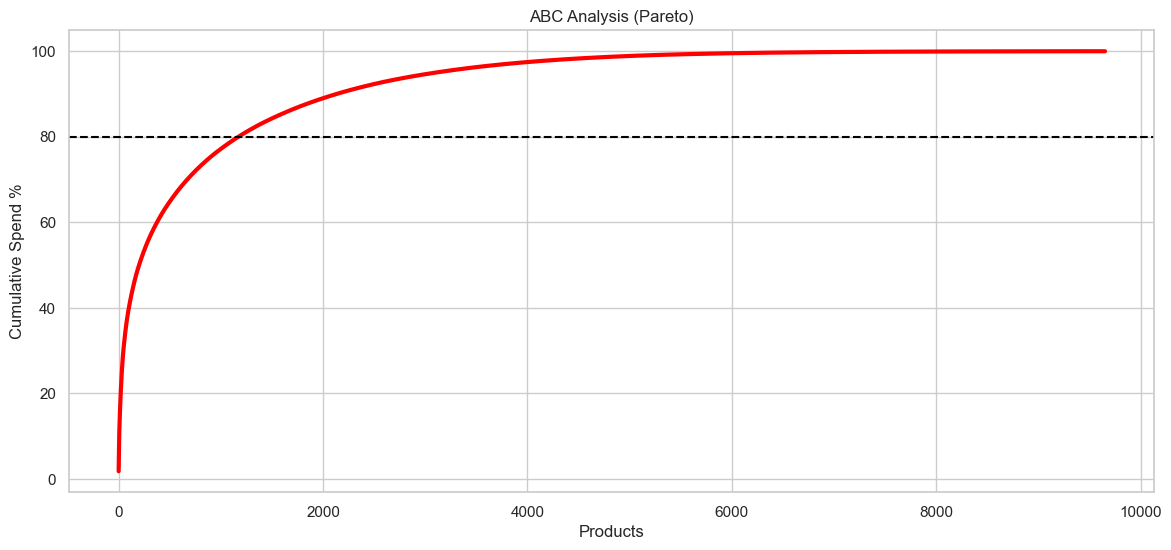

In [24]:
abc = (purchases_df.groupby('Description')['Dollars'].sum().sort_values(ascending=False).reset_index())

abc['CumSpend'] = abc['Dollars'].cumsum()

abc['CumPercent'] = (abc['CumSpend'] / abc['Dollars'].sum())*100

abc.head(20)

plt.figure(figsize=(14,6))

plt.plot(abc.index,abc['CumPercent'],linewidth=3,color='red')


plt.axhline(80,linestyle='--',color='black')

plt.title("ABC Analysis (Pareto)")
plt.xlabel("Products")
plt.ylabel("Cumulative Spend %")

plt.show()

In [26]:
abc['ABC_Class'] = 'C'

abc.loc[abc['CumPercent'] <= 80,'ABC_Class'] = 'A'

abc.loc[(abc['CumPercent'] > 80) & (abc['CumPercent'] <= 95),'ABC_Class'] = 'B'
abc['ABC_Class'].value_counts()

ABC_Class
C    6554
B    1926
A    1172
Name: count, dtype: int64

In [28]:
abc_summary = (abc.groupby('ABC_Class').agg(Products=('Description', 'count'),PurchaseValue=('Dollars','sum')))

abc_summary['Contribution %'] = (abc_summary['PurchaseValue']/abc_summary['PurchaseValue'].sum())*100
abc_summary

,Products,PurchaseValue,Contribution %
ABC_Class,,,
A,1172,2.575188e+08,79.999442
B,1926,4.828105e+07,14.998738
C,6554,1.610090e+07,5.001821


- Procurement efforts should prioritize Category A products, as a relatively small number of products account for the majority of procurement expenditure. Category B products require periodic monitoring, while Category C products can be managed with simpler inventory policies.

# Vendor spend vs Lead time

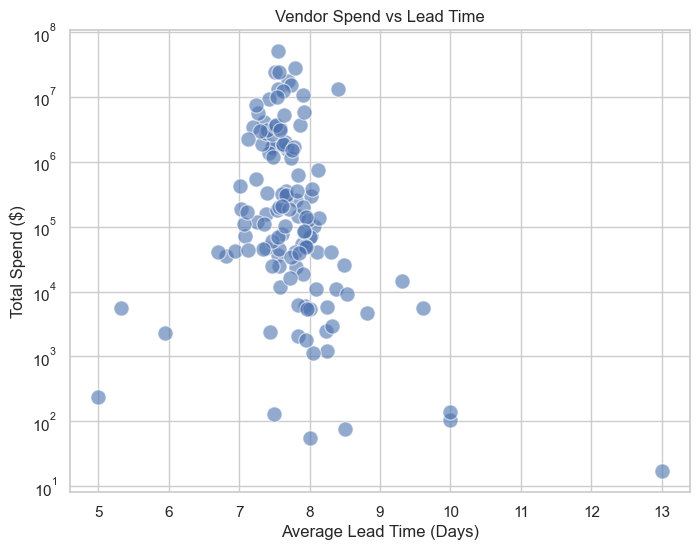

In [62]:
vendor = (purchases_df.groupby('VendorName').agg(Spend=('Dollars','sum'),Lead=('Lead_time_in_days','mean')))

plt.figure(figsize=(8,6))

sns.scatterplot(data=vendor,x='Lead',y='Spend',s=120, alpha=0.6)

plt.title("Vendor Spend vs Lead Time")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Total Spend ($)")
plt.yscale('log')
plt.show()

- Most vendors have average lead times concentrated between 7 and 8 days
- There is no obvious relationship between procurement spend and lead time
- High procurement spend vendors are distributed across similar lead times rather than having consistently shorter or longer delivery times

# Purchase price distribution

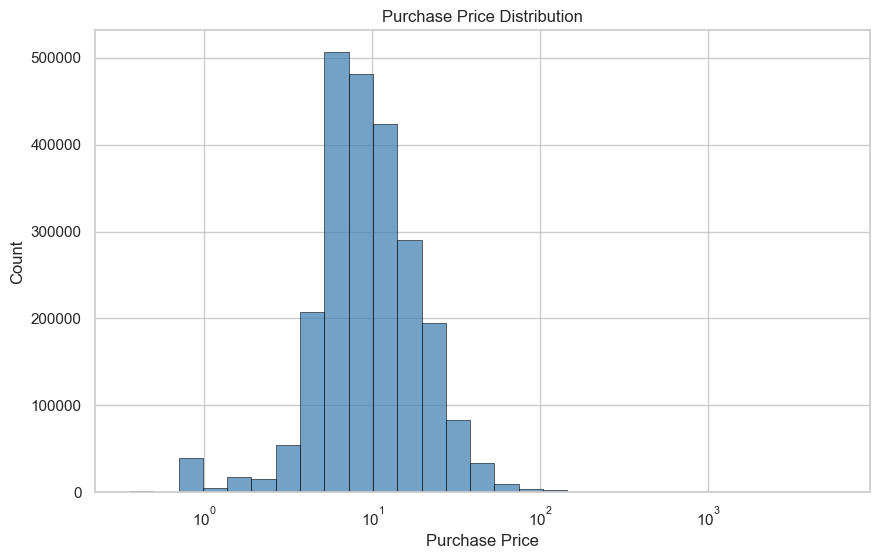

In [60]:
import numpy as np
plt.figure(figsize=(10,6))

plot_df = purchases_df[purchases_df['PurchasePrice'] > 0]['PurchasePrice']

bins = np.logspace(
    np.log10(plot_df.min()),
    np.log10(plot_df.max()),
    30
)
sns.histplot(plot_df['PurchasePrice'],kde=False,color='steelblue',edgecolor='black',linewidth=0.4,bins=bins)

plt.title("Purchase Price Distribution")
plt.xlabel("Purchase Price")
plt.ticklabel_format(style='plain', axis='y')
plt.xscale("log")
plt.show()

- Procurement primarily consists of lower-priced products, while premium products represent a relatively small but important portion of the product portfolio and should be monitored separately because of their higher financial impact

# Purchase order value distribution

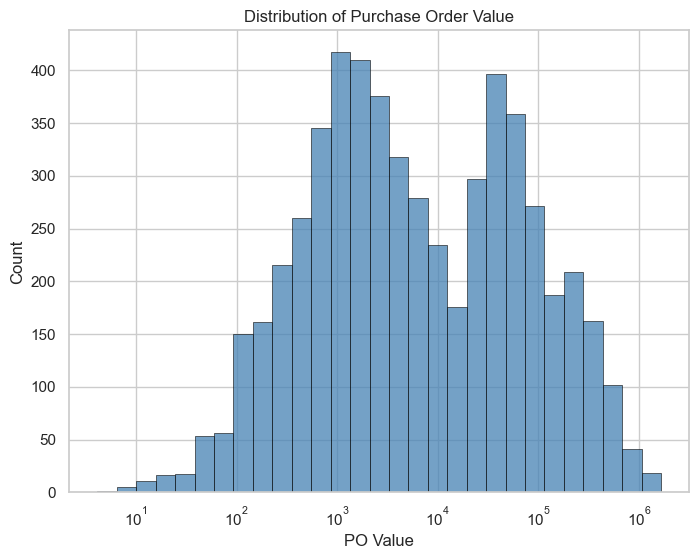

In [61]:
po = (purchases_df.groupby('PONumber')['Dollars'].sum())

bins = np.logspace(
    np.log10(po.min()),
    np.log10(po.max()),
    30
)

plt.figure(figsize=(8,6))

sns.histplot(po,kde=False,color='steelblue',edgecolor='black',linewidth=0.4, bins=bins)

plt.title("Distribution of Purchase Order Value")
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel("PO Value")
plt.xscale("log")
plt.show()

- Procurement appears to follow a mixed purchasing strategy, consisting of frequent lower-value purchase orders along with a smaller number of high-value bulk procurement transactions

# Final insights

- Procurement spend follows the Pareto principle, with a relatively small proportion of products contributing the majority of purchasing expenditure.
- Most suppliers maintain consistent lead times, although a few vendors require significantly longer replenishment periods and may need proactive inventory planning.
- Procurement spend and supplier lead time show no strong relationship, indicating that larger purchasing volumes do not necessarily result in faster deliveries.
- Purchase prices and purchase order values are highly right-skewed, with a small number of premium products and bulk purchase orders accounting for a significant share of procurement spending.
- Monthly procurement trends indicate seasonal fluctuations, supporting more effective procurement scheduling and inventory planning